https://psicode.org/psi4manual/master/api/psi4.core.Wavefunction.html#psi4.core.Wavefunction

In [10]:
import pickle, os, numpy as np

In [11]:
dataroot = "/root/limlab01/kaistai/25DFT/data/QM9_sample"
datalist = sorted([os.path.join(dataroot, fname) for fname in os.listdir(dataroot)])

In [12]:
with open(datalist[1], 'rb') as f:
	data = pickle.load(f)
	data = data[list(data.keys())[0]]

In [13]:
def print_dict_structure(d, indent=0, print_type=False, index_path=""):
    """Recursively print dictionary structure with hierarchical numbering."""
    if isinstance(d, dict):
        for idx, k in enumerate(d.keys(), 1):
            # Build current index path
            current_index = f"{index_path}-{idx}" if index_path else str(idx)
            type_info = f" [{type(d[k]).__name__}]" if print_type else ""
            print("  " * indent + f"{current_index}. {k}{type_info}")
            print_dict_structure(d[k], indent + 1, print_type, current_index)
    elif isinstance(d, list):
        type_info = f" [list of {type(d[0]).__name__}]" if d and print_type else ""
        print("  " * indent + f"[list] (len={len(d)}){type_info}")
        if d and isinstance(d[0], (dict, list)):
            print_dict_structure(d[0], indent + 1, print_type, index_path)
    else:
        pass
        # if print_type:
        #     print("  " * indent + f"[{type(d).__name__}]")

print_dict_structure(data, print_type=True)

1. energy [float]
2. total_time [float]
3. energy_time [float]
4. gradient_time [float]
5. wavefunction [dict]
  5-1. molecule [dict]
    5-1-1. provenance [dict]
      5-1-1-1. creator [str]
      5-1-1-2. routine [str]
      5-1-1-3. version [str]
    5-1-2. units [str]
    5-1-3. geom [ndarray]
    5-1-4. elea [ndarray]
    5-1-5. elez [ndarray]
    5-1-6. elem [ndarray]
    5-1-7. mass [ndarray]
    5-1-8. real [ndarray]
    5-1-9. elbl [ndarray]
    5-1-10. fragment_separators [list]
      [list] (len=0)
    5-1-11. molecular_charge [float]
    5-1-12. fragment_charges [list]
      [list] (len=1) [list of float]
    5-1-13. molecular_multiplicity [int]
    5-1-14. fragment_multiplicities [list]
      [list] (len=1) [list of int]
    5-1-15. fix_com [bool]
    5-1-16. fix_orientation [bool]
  5-2. matrix [dict]
    5-2-1. Ca [ndarray]
    5-2-2. Cb [ndarray]
    5-2-3. Da [ndarray]
    5-2-4. Db [ndarray]
    5-2-5. Fa [ndarray]
    5-2-6. Fb [ndarray]
    5-2-7. H [ndarray]
    5-

In [14]:
data

{'energy': -56.59637669798353,
 'total_time': 6.127204418182373,
 'energy_time': 4.5299530029296875e-06,
 'gradient_time': 6.126387357711792,
 'wavefunction': {'molecule': {'provenance': {'creator': 'QCElemental',
    'routine': 'qcelemental.molparse.from_string',
    'version': '0.29.0'},
   'units': 'Angstrom',
   'geom': array([-0.031611  ,  0.02116096,  0.06033786,  0.02607252, -0.99040158,
          -0.0296031 ,  0.92460442,  0.35579841, -0.0309837 , -0.51146268,
           0.34058534, -0.77776855]),
   'elea': array([14,  1,  1,  1]),
   'elez': array([7, 1, 1, 1]),
   'elem': array(['N', 'H', 'H', 'H'], dtype='<U1'),
   'mass': array([14.003074  ,  1.00782503,  1.00782503,  1.00782503]),
   'real': array([ True,  True,  True,  True]),
   'elbl': array(['', '', '', ''], dtype='<U1'),
   'fragment_separators': [],
   'molecular_charge': 0.0,
   'fragment_charges': [0.0],
   'molecular_multiplicity': 1,
   'fragment_multiplicities': [1],
   'fix_com': False,
   'fix_orientation': F

In [16]:
data["wavefunction"]["molecule"]

{'provenance': {'creator': 'QCElemental',
  'routine': 'qcelemental.molparse.from_string',
  'version': '0.29.0'},
 'units': 'Angstrom',
 'geom': array([-0.031611  ,  0.02116096,  0.06033786,  0.02607252, -0.99040158,
        -0.0296031 ,  0.92460442,  0.35579841, -0.0309837 , -0.51146268,
         0.34058534, -0.77776855]),
 'elea': array([14,  1,  1,  1]),
 'elez': array([7, 1, 1, 1]),
 'elem': array(['N', 'H', 'H', 'H'], dtype='<U1'),
 'mass': array([14.003074  ,  1.00782503,  1.00782503,  1.00782503]),
 'real': array([ True,  True,  True,  True]),
 'elbl': array(['', '', '', ''], dtype='<U1'),
 'fragment_separators': [],
 'molecular_charge': 0.0,
 'fragment_charges': [0.0],
 'molecular_multiplicity': 1,
 'fragment_multiplicities': [1],
 'fix_com': False,
 'fix_orientation': False}

In [99]:
# 0-1: finding number of orbitals
import pyscf.gto

orbital_list = {}

def get_orbital_list(atomic_symbol, basis="def2tzvppd"):
    if basis not in orbital_list:   
        orbital_list[basis] = {}
    if atomic_symbol in orbital_list[basis]:
        return orbital_list[basis][atomic_symbol]
    else:
        orbital_data = pyscf.gto.basis.load(basis, atomic_symbol)
        orb_list = []
        orbstr_list = []
        orbstr = "spdfghi"
        for orb in orbital_data:
            orb_rank = orb[0]
            orb_list.append(orb_rank + 1)
            orb_idx = orb_list.count(orb_rank + 1) + orb_rank - 1
            orbstr_list.append(f"{orb_idx+1}{orbstr[orb_rank]}")
        orbital_list[atomic_symbol] = orb_list, orbstr_list
        return orb_list, orbstr_list

def get_orbital_list_from_atomic_symbol(atomic_symbols, basis="def2tzvppd"):
    tot_orb_list = []
    tot_orbstr_list = []
    for sym in atomic_symbols:
        orb_list, orbstr_list = get_orbital_list(sym, basis)
        tot_orb_list.extend(orb_list)
        tot_orbstr_list.extend(orbstr_list)
    return tot_orb_list, tot_orbstr_list

In [100]:
# 0. Molecule geometry & energy, forces
atomic_number = data["wavefunction"]["molecule"]["elez"]
atomic_symbol = data["wavefunction"]["molecule"]["elem"]
# num_elec = data["wavefunction"]["molecule"]["elea"]
pos = data["wavefunction"]["molecule"]["geom"].reshape(-1, 3)
orb_list, orbstr_list = get_orbital_list_from_atomic_symbol(atomic_symbol)

energy = data["energy"]
forces = -data["gradient"] # force_i = - dE/dpos_i

print("Length unit:", data["wavefunction"]["molecule"]["units"])
print("pos.dtype:", pos.dtype)
print("atomic_number:", atomic_number)
print("atomic_symbol:", atomic_symbol)
print("pos:", pos)
print("energy:", energy) # E_h (atomic unit)
print("forces:", forces) # E_h/bohr (atomic unit)
print("Ham_dim:", sum(orb_list) * 2 - len(orb_list))
print(orb_list)
print(orbstr_list)

Length unit: Angstrom
pos.dtype: float64
atomic_number: [7 1 1 1]
atomic_symbol: ['N' 'H' 'H' 'H']
pos: [[-0.031611    0.02116096  0.06033786]
 [ 0.02607252 -0.99040158 -0.0296031 ]
 [ 0.92460442  0.35579841 -0.0309837 ]
 [-0.51146268  0.34058534 -0.77776855]]
energy: -56.59637669798353
forces: [[ 0.00364191 -0.00244012 -0.00693918]
 [-0.00091124  0.0031645   0.00164771]
 [-0.00326799 -0.00036879  0.00165159]
 [ 0.00053817 -0.00035663  0.00364018]]
Ham_dim: 88
[1, 1, 1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 1, 1, 1, 2, 2, 2, 3, 1, 1, 1, 2, 2, 2, 3, 1, 1, 1, 2, 2, 2, 3]
['1s', '2s', '3s', '4s', '5s', '6s', '2p', '3p', '4p', '3d', '4d', '5d', '4f', '1s', '2s', '3s', '2p', '3p', '4p', '3d', '1s', '2s', '3s', '2p', '3p', '4p', '3d', '1s', '2s', '3s', '2p', '3p', '4p', '3d']


In [ ]:
sum(orb_list) * 2 - len(orb_list)


88

In [86]:
get_orbital_list("N")

([1, 1, 1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4],
 ['1s',
  '1p',
  '1d',
  '1f',
  '1g',
  '1h',
  '2p',
  '2d',
  '2f',
  '3d',
  '3f',
  '3g',
  '4f'])

In [18]:
# Visualize with py3Dmol
import py3Dmol

def atom_data_to_xyz(atomic_numbers, positions):
    """Convert atomic data to XYZ format string"""
    # Element symbols mapping
    element_map = {
        1: 'H', 2: 'He', 3: 'Li', 4: 'Be', 5: 'B', 6: 'C', 7: 'N', 8: 'O', 
        9: 'F', 10: 'Ne', 11: 'Na', 12: 'Mg', 13: 'Al', 14: 'Si', 15: 'P', 
        16: 'S', 17: 'Cl', 18: 'Ar', 19: 'K', 20: 'Ca', 35: 'Br', 53: 'I'
    }
    
    # Convert Bohr to Angstrom (1 Bohr = 0.529177 Angstrom)
    # bohr_to_angstrom = 0.529177210903
    positions_angstrom = positions
    
    # Build XYZ format
    n_atoms = len(atomic_numbers)
    xyz = f"{n_atoms}\n"
    xyz += "Molecule from DFT calculation\n"
    
    for z, pos in zip(atomic_numbers, positions_angstrom):
        symbol = element_map.get(int(z), f'X{int(z)}')
        xyz += f"{symbol:2s} {pos[0]:12.6f} {pos[1]:12.6f} {pos[2]:12.6f}\n"
    
    return xyz

def view_molecule_3d(atomic_numbers, positions, size=(600, 400), style='stick', surface=False, opacity=0.5):
    """Visualize molecule in 3D using py3Dmol"""
    assert style in ('line', 'stick', 'sphere', 'cartoon')
    
    # Convert to XYZ format
    xyz_data = atom_data_to_xyz(atomic_numbers, positions)
    
    # Create viewer
    viewer = py3Dmol.view(width=size[0], height=size[1])
    viewer.addModel(xyz_data, 'xyz')
    viewer.setStyle({"stick": {"radius": 0.05}, "sphere": {"scale": 0.2}})
    
    if surface:
        viewer.addSurface(py3Dmol.SAS, {'opacity': opacity})
    
    viewer.zoomTo()
    return viewer

# Visualize the molecule
viewer = view_molecule_3d(atomic_number, pos, size=(800, 600), style='sphere', opacity=0.5)
viewer.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [19]:
# 1. Hamiltonian matrix
H = data["wavefunction"]["matrix"]["Fa"] # is the same with data["wavefunction"]["matrix"]["Fb"]
print(np.allclose(H, data["wavefunction"]["matrix"]["Fb"]))
print(H.shape)
print(H)

True
(88, 88)
[[-6.07168279e+00 -1.58152121e+01 -6.20970737e+00 ...  6.76457618e-01
  -1.62330022e-01  3.88092261e-01]
 [-1.58152121e+01 -1.03181219e+01 -5.64258208e+00 ...  7.12674831e-01
  -1.70728430e-01  4.08165944e-01]
 [-6.20970737e+00 -5.64258208e+00 -3.13442642e+00 ...  3.34132128e-01
  -7.96728835e-02  1.90470618e-01]
 ...
 [ 6.76457618e-01  7.12674831e-01  3.34132128e-01 ...  2.97264713e+00
  -4.15128621e-02 -1.21702278e-01]
 [-1.62330022e-01 -1.70728430e-01 -7.96728835e-02 ... -4.15128621e-02
   3.11940713e+00  7.57919209e-03]
 [ 3.88092261e-01  4.08165944e-01  1.90470618e-01 ... -1.21702278e-01
   7.57919209e-03  3.10448019e+00]]


In [20]:
# 2. Overlap matrix
S = data["wavefunction"]["matrix"]["S"]
print(S.shape)
print(S)

(88, 88)
[[ 1.          0.68327429  0.19009388 ... -0.01940923  0.00464822
  -0.01111261]
 [ 0.68327429  1.          0.53789416 ... -0.06501111  0.01556917
  -0.03722163]
 [ 0.19009388  0.53789416  1.         ... -0.13945717  0.03339787
  -0.07984518]
 ...
 [-0.01940923 -0.06501111 -0.13945717 ...  1.          0.
   0.        ]
 [ 0.00464822  0.01556917  0.03339787 ...  0.          1.
   0.        ]
 [-0.01111261 -0.03722163 -0.07984518 ...  0.          0.
   1.        ]]


In [21]:
# 3. Coefficient matrix
C = data["wavefunction"]["matrix"]["Ca"]
print(np.allclose(C, data["wavefunction"]["matrix"]["Cb"]))
print(C.shape)
print(C)

True
(88, 88)
[[ 4.49978135e-01  9.38019769e-02  5.87212069e-06 ... -8.17455550e-06
  -1.43048192e-07  1.40211775e+00]
 [ 6.26740593e-01  2.13279329e-01  1.36273856e-05 ...  1.72943937e-06
  -9.34257128e-07 -1.78885332e+00]
 [ 3.06236364e-02 -3.30945840e-01 -1.99130834e-05 ... -8.06006008e-04
   1.46391260e-05  1.81100461e+00]
 ...
 [ 3.24320800e-04  1.91558912e-03  2.85873433e-03 ...  3.84494933e-01
   2.55842823e-01  7.81087087e-02]
 [-6.46784256e-05 -4.41474611e-04 -4.42273027e-04 ... -1.24295961e-01
   1.87810522e-01 -1.93405637e-02]
 [ 1.54412402e-04  1.05536722e-03  1.06746511e-03 ...  3.02194848e-01
   7.52887043e-02  4.62492968e-02]]


In [22]:
# 4. epsilon
E = data["wavefunction"]["vector"]["epsilon_a"]
print(np.allclose(E, data["wavefunction"]["vector"]["epsilon_b"]))
print(E.shape)
print(E)

True
(88,)
[-14.48681488  -0.97857953  -0.56597622  -0.56593927  -0.38133693
   0.04465241   0.12103007   0.12103595   0.17084794   0.18503029
   0.18503682   0.22465045   0.22465887   0.22498133   0.29381633
   0.33346457   0.35191676   0.35191776   0.42046519   0.42046796
   0.4684906    0.50884357   0.50885136   0.64464658   0.66024017
   0.68844114   0.68847308   0.76388275   0.76391439   0.89802046
   1.02741141   1.02745602   1.15057129   1.1522419    1.26922536
   1.26927853   1.30426196   1.30428619   1.45182202   1.64790207
   1.69794921   1.69796548   1.8286245    1.82863891   2.30341565
   2.53304575   2.53305008   2.61447615   2.8311194    2.99713757
   2.99715142   3.15502863   3.31281781   3.36690159   3.36698312
   3.38154062   3.3816573    3.54873671   3.58644865   3.58647088
   3.88724595   3.92723282   3.92727148   3.99318862   3.9990574
   3.99909602   4.18853887   4.18858992   4.42907298   4.51378619
   4.51382513   4.54484998   4.80253408   4.9953386    4.99539875


In [23]:
# Basic properties:
# Prop1:  HC=SCE
HC = np.dot(H, C)
E_d = np.diag(E)
SCE = np.dot(S, np.dot(C, E_d))

if np.allclose(HC, SCE):
    print("Success: HC=SCE")
else:
    print("Failed: HC=SCE")

Success: HC=SCE


In [24]:
# Prop2: (C.T)SC = I
C_SC = np.dot(C.T, np.dot(S, C))

if np.allclose(C_SC, np.eye(C_SC.shape[0])):
    print("Success: (C.T)SC = I")
else:
    print("Failed: (C.T)SC = I")

Success: (C.T)SC = I


In [ ]:
# Check density matrix is correct
num_orb = int(atomic_number.sum() / 2) # occupied orbitals
sliced_C = C[:,:int(num_orb)]
dm = np.dot(sliced_C, sliced_C.T) * 2 # multiply 2 for spin-unpolarized
np.allclose(dm, data["wavefunction"]["matrix"]["Da"] * 2)

True

In [25]:
import matplotlib.pyplot as plt

def matshow(matrix, max_val=None, max_mul=0.1, colorbar=True, frame=True, ticks=False, save_name=None, drawline=[], ratio=0.8):
    fig, ax = plt.subplots(figsize=(6*ratio,5*ratio))
    if matrix.ndim == 3:
        matrix = matrix[0]
    if max_val is None:
        max_val = abs(matrix).max() * max_mul
    im = ax.imshow(matrix, cmap='bwr',vmin=-max_val, vmax=max_val)
    if colorbar:
        fig.colorbar(im)
    if not ticks:
        ax.set_xticks([])
        ax.set_yticks([])
    
    spines_name = ['top', 'right', 'bottom', 'left']
    for spine in spines_name:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.5)
    
    if not frame: 
        for spine in spines_name:
            ax.spines[spine].set_visible(False)
    
    cur = 0
    for idx, orb_num in enumerate(drawline):
        color = 'gray'
        ls = '--'
        lw = 0.3
        if orb_num < 0:
            orb_num = -orb_num
            color = 'black'
            ls = '-'
            lw = 0.5
        cur = cur + orb_num
        ax.axhline(y=cur-0.5, color=color, linestyle=ls, linewidth=lw)
        ax.axvline(x=cur-0.5, color=color, linestyle=ls, linewidth=lw)
    if save_name is not None:
        plt.savefig(save_name, bbox_inches='tight', dpi=600)
    plt.show()
    
    return max_val

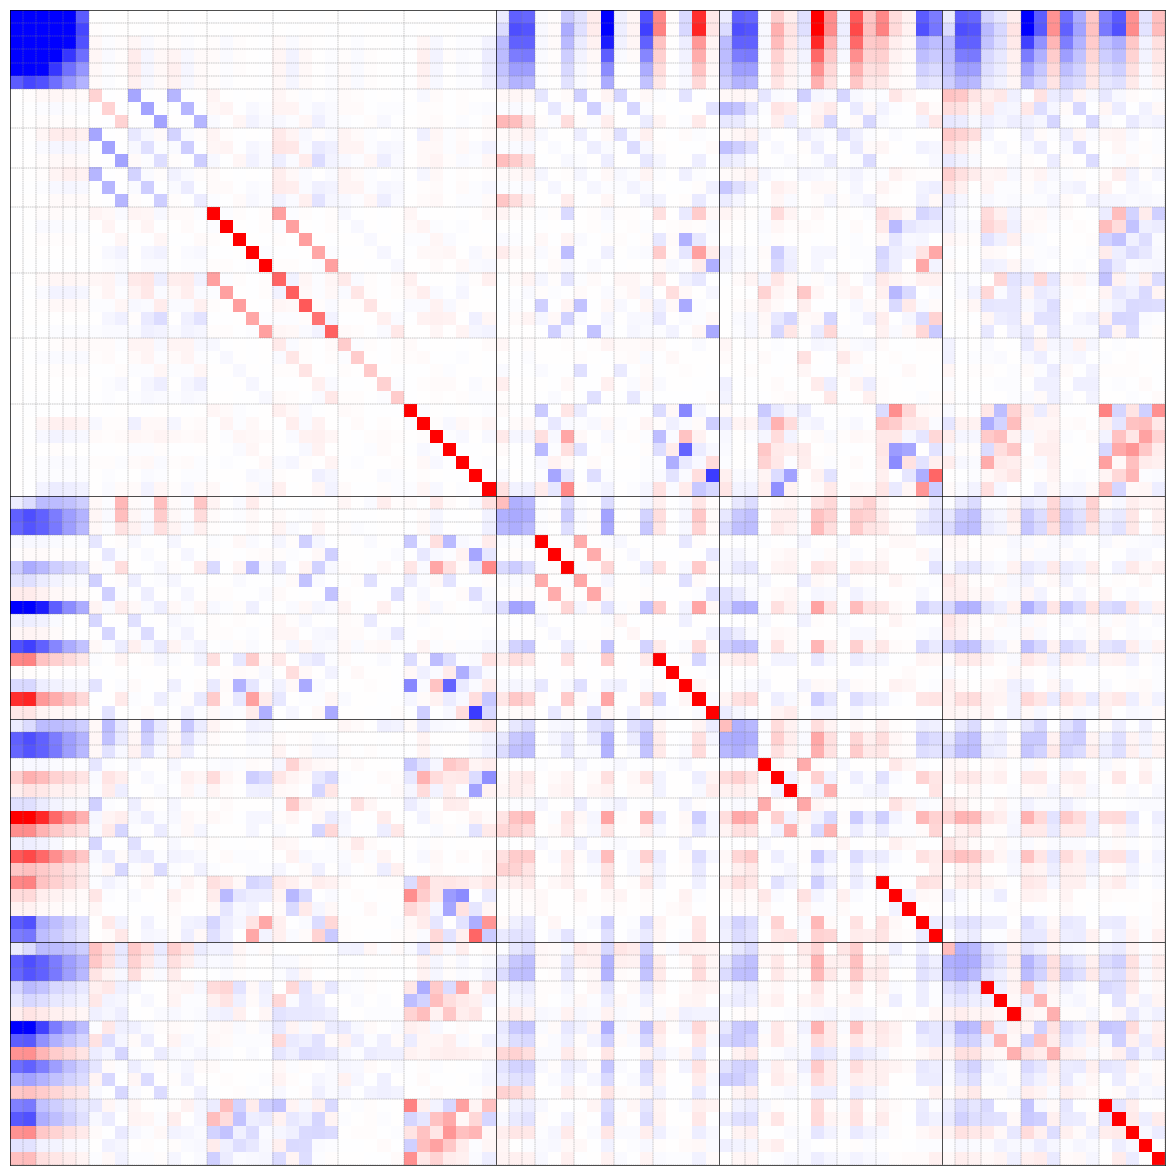

1.5815212112152301

In [ ]:
orb_lines = [
    1, 1, 1, 1, 1, 1, 3, 3, 3, 5, 5, 5, -7, # N
    1, 1, 1, 3, 3, 3, -5, # H
    1, 1, 1, 3, 3, 3, -5, # H
    1, 1, 1, 3, 3, 3, 5, # H
    ]
# N : 1s, 2s, 3s, 4s, 5s, 6s, 2p, 3p, 4p, 3d, 4d, 5d, 4f
# H : 1s, 2s, 3s, 2p, 3p, 4p, 3d
# H : 1s, 2s, 3s, 2p, 3p, 4p, 3d

matshow(H, drawline=orb_lines, ratio=3, colorbar=False)

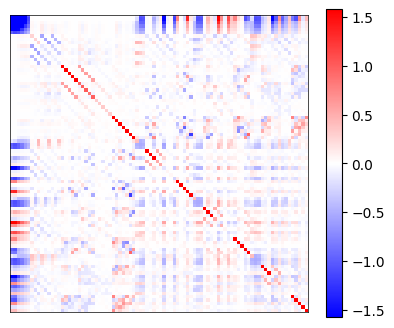

1.5815212112152301

In [27]:
matshow(H)

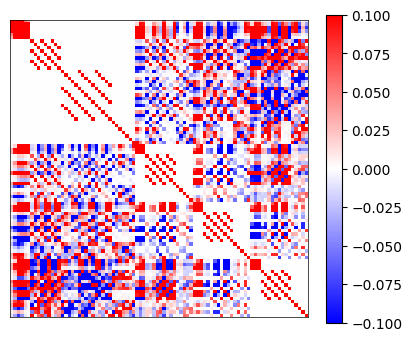

0.10000000000000014

In [28]:
matshow(S)

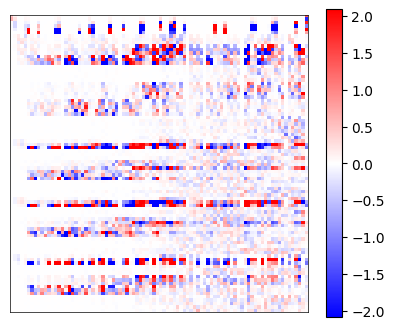

2.092651713680758

In [29]:
matshow(C)

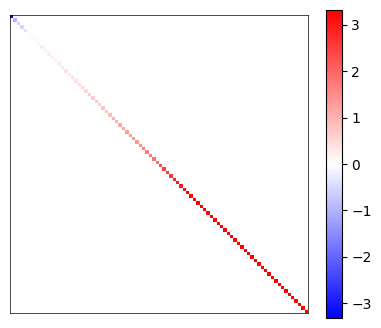

3.312403048943766

In [30]:
matshow(E_d)